Name: Tanvi Gajanan Upganlawar

Roll no: 12

PRN no: 1252090012


---



Assignment 9

Write a program to do following:

This dataset gives the data of Income and money spent by the customers visiting a shopping mall. The data set contains Customer ID, Gender, Age, Annual Income, Spending Score. Therefore, as a mall owner you need to find the group of people who are the profitable customers for the mall owner. Apply at least two clustering algorithms (based on Spending Score) to find the group of customers.

Apply Data pre-processing
Perform data-preparation (Train-Test Split)
Apply Machine Learning Algorithm
Evaluate Model.
      Data Set: https://www.kaggle.com/shwetabh123/mall-customers

In [ ]:
import pandas as pd

# Load dataset
dataset = pd.read_csv('Mall_Customers.csv')

dataset.head()

,CustomerID,Genre,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


data preprocessing

In [ ]:

dataset.rename(columns={'Genre': 'Gender'}, inplace=True)

print(dataset.isnull().sum())

dataset.fillna(dataset.mean(numeric_only=True), inplace=True)

dataset['Gender'] = dataset['Gender'].map({'Male': 0, 'Female': 1})

X = dataset[['Annual Income (k$)', 'Spending Score (1-100)']]

print(X.head())

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64
   Annual Income (k$)  Spending Score (1-100)
0                  15                      39
1                  15                      81
2                  16                       6
3                  16                      77
4                  17                      40


feature scaling

In [ ]:

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

elbow method

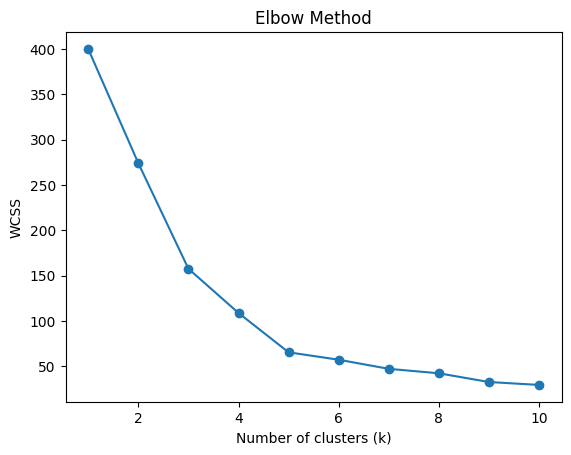

In [ ]:

import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=0)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss, marker='o')
plt.title('Elbow Method')
plt.xlabel('Number of clusters (k)')
plt.ylabel('WCSS')
plt.show()

K-means model

In [ ]:

from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=5, random_state=0)

y_kmeans = kmeans.fit_predict(X_scaled)

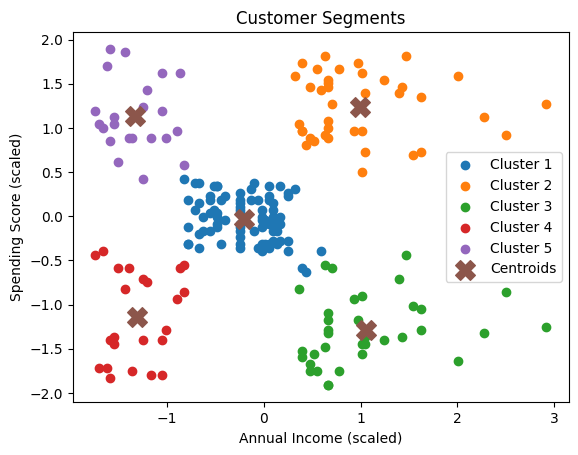

In [ ]:
#visualizing the clusters
import matplotlib.pyplot as plt

plt.scatter(X_scaled[y_kmeans == 0, 0], X_scaled[y_kmeans == 0, 1], label='Cluster 1')
plt.scatter(X_scaled[y_kmeans == 1, 0], X_scaled[y_kmeans == 1, 1], label='Cluster 2')
plt.scatter(X_scaled[y_kmeans == 2, 0], X_scaled[y_kmeans == 2, 1], label='Cluster 3')
plt.scatter(X_scaled[y_kmeans == 3, 0], X_scaled[y_kmeans == 3, 1], label='Cluster 4')
plt.scatter(X_scaled[y_kmeans == 4, 0], X_scaled[y_kmeans == 4, 1], label='Cluster 5')

plt.scatter(kmeans.cluster_centers_[:, 0], kmeans.cluster_centers_[:, 1],
            s=200, marker='X', label='Centroids')

plt.title('Customer Segments')
plt.xlabel('Annual Income (scaled)')
plt.ylabel('Spending Score (scaled)')
plt.legend()
plt.show()

silhouette score

In [ ]:

from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, y_kmeans)

print("Silhouette Score (K-Means):", score)

Silhouette Score (K-Means): 0.5546571631111091


k-means++ model

In [ ]:

kmeans_pp = KMeans(n_clusters=3, init='k-means++', random_state=0)

y_kmeans_pp = kmeans_pp.fit_predict(X_scaled)

In [ ]:
from sklearn.metrics import silhouette_score

score_pp = silhouette_score(X_scaled, y_kmeans_pp)
print("K-Means++ Silhouette Score:", score_pp)

K-Means++ Silhouette Score: 0.46658474419000145


KNN

In [ ]:
def categorize(score):
    if score < 40:
        return 0
    elif score < 70:
        return 1
    else:
        return 2

dataset['Spending_Category'] = dataset['Spending Score (1-100)'].apply(categorize)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


X = dataset[['Age', 'Annual Income (k$)']]
y = dataset['Spending_Category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

from sklearn.neighbors import KNeighborsClassifier

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

from sklearn.metrics import accuracy_score, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.75
Confusion Matrix:
 [[11  2  0]
 [ 0 11  3]
 [ 1  4  8]]


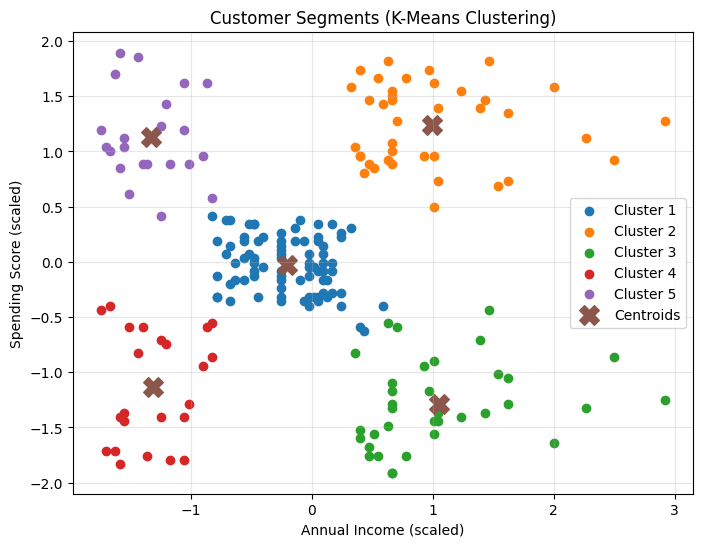

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))


plt.scatter(
    X_scaled[y_kmeans == 0, 0], X_scaled[y_kmeans == 0, 1],
    label='Cluster 1'
)

plt.scatter(
    X_scaled[y_kmeans == 1, 0], X_scaled[y_kmeans == 1, 1],
    label='Cluster 2'
)

plt.scatter(
    X_scaled[y_kmeans == 2, 0], X_scaled[y_kmeans == 2, 1],
    label='Cluster 3'
)

plt.scatter(
    X_scaled[y_kmeans == 3, 0], X_scaled[y_kmeans == 3, 1],
    label='Cluster 4'
)

plt.scatter(
    X_scaled[y_kmeans == 4, 0], X_scaled[y_kmeans == 4, 1],
    label='Cluster 5'
)

plt.scatter(
    kmeans.cluster_centers_[:, 0],
    kmeans.cluster_centers_[:, 1],
    s=200,
    marker='X',
    label='Centroids'
)

plt.title('Customer Segments (K-Means Clustering)')
plt.xlabel('Annual Income (scaled)')
plt.ylabel('Spending Score (scaled)')
plt.legend()
plt.grid(alpha=0.3)

plt.show()